# **Real Estate Investment Advisor: Predicting Property Profitability & Future Value**


In [4]:
# Clone your repo
!git clone https://github.com/Sabitha-23/Real-Estate-Investment-Advisor.git
%cd Real-Estate-Investment-Advisor

# Config git identity
!git config --global user.email "sabithaj2001@gmail.com"
!git config --global user.name "Sabitha-23"

Cloning into 'Real-Estate-Investment-Advisor'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 168 (delta 46), reused 83 (delta 17), pack-reused 45 (from 1)
Receiving objects: 100% (168/168), 38.50 MiB | 18.75 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/Real-Estate-Investment-Advisor


Install and Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")

✅ All libraries imported!


Download Dataset

In [7]:
!git clone  https://github.com/Sabitha-23/Real-Estate-Investment-Advisor.git
%cd Real-Estate-Investment-Advisor

!gdown "https://drive.google.com/uc?id=1ys25Eaqo2n8IeHhyI9s0kmJBgnNzxQHX" -O data/india_housing_prices.csv

df = pd.read_csv("data/india_housing_prices.csv")

print(" Shape:", df.shape)
print("\n Columns:\n", df.columns.tolist())
print("\n Data Types:\n", df.dtypes)
df.head()

Cloning into 'Real-Estate-Investment-Advisor'...
remote: Enumerating objects: 168, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 168 (delta 46), reused 83 (delta 17), pack-reused 45 (from 1)
Receiving objects: 100% (168/168), 38.50 MiB | 15.61 MiB/s, done.
Resolving deltas: 100% (57/57), done.
/content/Real-Estate-Investment-Advisor/Real-Estate-Investment-Advisor/Real-Estate-Investment-Advisor
Downloading...
From: https://drive.google.com/uc?id=1ys25Eaqo2n8IeHhyI9s0kmJBgnNzxQHX
To: /content/Real-Estate-Investment-Advisor/Real-Estate-Investment-Advisor/Real-Estate-Investment-Advisor/data/india_housing_prices.csv
100% 41.1M/41.1M [00:00<00:00, 42.0MB/s]
 Shape: (250000, 23)

 Columns:
 ['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Publ

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


Basic info check

In [8]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Duplicates ===")
print("Duplicate rows:", df.duplicated().sum())

print("\n=== Basic Stats ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  


,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


Inspect Missing values and Duplicate values

In [9]:
print("=" * 50)
print(" MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n" + "=" * 50)
print(" DUPLICATES")
print("=" * 50)
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 50)
print(" BASIC STATS")
print("=" * 50)
df.describe()

 MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

 DUPLICATES
Duplicate rows: 0

 BASIC STATS


,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


Handle Duplicates

In [10]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]

print(f" Removed {before - after} duplicate rows")
print(f" New shape: {df.shape}")

 Removed 0 duplicate rows
 New shape: (250000, 23)


Handle Missing values

In [11]:
# ── Numerical columns → fill with MEDIAN ──
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"   {col}: filled with median = {median_val:.2f}")

# ── Categorical columns → fill with MODE ──
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"   {col}: filled with mode = '{mode_val}'")

print(f"\n Total missing values remaining: {df.isnull().sum().sum()}")


 Total missing values remaining: 0


Scale Numerical Features

In [12]:
# Drop non-numeric/target/id columns before scaling
drop_for_scaling = ['ID', 'Year_Built', 'Price_Category',
                    'Good_Investment', 'Future_Price_5yr', 'Rule_Score']

scale_cols = [col for col in df.select_dtypes(include=np.number).columns
              if col not in drop_for_scaling]

print(f"📊 Columns to scale ({len(scale_cols)}):\n{scale_cols}")

# StandardScaler (mean=0, std=1) — best for ML models
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

# Save scaler
joblib.dump(scaler, "models/scaler.pkl")

print("\n Scaling done!")
print(df_scaled[scale_cols].describe().round(2))

📊 Columns to scale (9):
['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']

 Scaling done!
             BHK  Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt   Floor_No  \
count  250000.00     250000.00       250000.00       250000.00  250000.00   
mean        0.00         -0.00            0.00            0.00       0.00   
std         1.00          1.00            1.00            1.00       1.00   
min        -1.41         -1.73           -1.73           -1.00      -1.67   
25%        -0.71         -0.87           -0.86           -0.62      -0.89   
50%         0.00         -0.00           -0.01           -0.31       0.00   
75%         0.71          0.86            0.87            0.22       0.90   
max         1.41          1.73            1.74            6.57       1.68   

       Total_Floors  Age_of_Property  Nearby_Schools  Nearby_Hospitals  
count     250000.00        250000.00       25000

Feature Engineering

In [13]:
# ── 1. Age of Property ──
df['Age_of_Property'] = 2025 - df['Year_Built'].astype(float)

# ── 2. Price per SqFt ──
if 'Price_per_SqFt' not in df.columns:
    df['Price_per_SqFt'] = df['Price_in_Lakhs'].astype(float) / df['Size_in_SqFt'].astype(float)

# ── 3. School Density Score ──
df['School_Density_Score'] = pd.cut(
    df['Nearby_Schools'].astype(float),
    bins=[0, 2, 5, 8, 100],
    labels=[1, 2, 3, 4]
).astype(float).fillna(1)

# ── 4. Hospital Density Score ──
df['Hospital_Density_Score'] = pd.cut(
    df['Nearby_Hospitals'].astype(float),
    bins=[0, 2, 5, 8, 100],
    labels=[1, 2, 3, 4]
).astype(float).fillna(1)

# Map 'Public_Transport_Accessibility' to numerical values
accessibility_mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}
df['Public_Transport_Accessibility_Numeric'] = df['Public_Transport_Accessibility'].map(accessibility_mapping).astype(float)

# ── 5. Infrastructure Score ──
df['Infrastructure_Score'] = (
    df['Nearby_Schools'].astype(float) * 0.3 +
    df['Nearby_Hospitals'].astype(float) * 0.3 +
    df['Public_Transport_Accessibility_Numeric'] * 0.4
).round(2)

# ── 6. Price Category ──
df['Price_Category'] = pd.cut(
    df['Price_in_Lakhs'].astype(float),
    bins=[0, 50, 100, 200, 500, 99999],
    labels=['Budget', 'Affordable', 'Mid-Range', 'Premium', 'Luxury']
)

# ── 7. Floor Ratio ──
df['Floor_Ratio'] = (
    df['Floor_No'].astype(float) /
    df['Total_Floors'].astype(float).replace(0, 1)
).round(3)

# ── 8. Value Score ──
df['Value_Score'] = (
    df['Infrastructure_Score'] / (df['Price_per_SqFt'] + 1)
).round(4)

print(" Feature Engineering done!")
print(df[['Age_of_Property', 'Price_per_SqFt', 'School_Density_Score',
          'Hospital_Density_Score', 'Infrastructure_Score',
          'Floor_Ratio', 'Value_Score']].head())

 Feature Engineering done!
   Age_of_Property  Price_per_SqFt  School_Density_Score  \
0             35.0            0.10                   4.0   
1             17.0            0.08                   3.0   
2             28.0            0.05                   4.0   
3             34.0            0.11                   2.0   
4             23.0            0.04                   2.0   

   Hospital_Density_Score  Infrastructure_Score  Floor_Ratio  Value_Score  
0                     2.0                   5.1       22.000       4.6364  
1                     1.0                   3.1        1.050       2.8704  
2                     3.0                   5.5        0.704       5.2381  
3                     3.0                   4.8        0.808       4.3243  
4                     4.0                   4.3        1.500       4.1346  


 Create Target Variable: Good Investment

 Good Investment Label:
Good_Investment
0    133240
1    116760
Name: count, dtype: int64

  Positive Rate : 46.7%
  Negative Rate : 53.3%


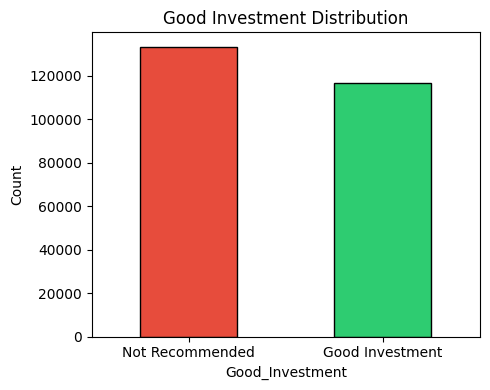

In [14]:
# Rule 1: Price per SqFt ≤ city-group median
# City column was frequency encoded → use City_Freq instead

# Ensure City_Freq exists for Rule 1 calculation
if 'City_Freq' not in df.columns and 'City' in df.columns:
    freq_map = df['City'].value_counts().to_dict()
    df['City_Freq'] = df['City'].map(freq_map)
    # Optionally, df.drop(columns=['City'], inplace=True) could be done here if City is no longer needed
    # but we'll leave it for now as the dedicated encoding cell will handle the drop.

city_median   = df.groupby('City_Freq')['Price_per_SqFt'].transform('median')
rule1         = (df['Price_per_SqFt'].astype(float) <= city_median.astype(float))

# Rule 2: BHK ≥ 2
rule2         = (df['BHK'].astype(float) >= 2)

# Rule 3: Infrastructure Score ≥ median
rule3         = (df['Infrastructure_Score'] >= df['Infrastructure_Score'].median())

# Rule 4: Age of property ≤ 20 years
rule4         = (df['Age_of_Property'].astype(float) <= 20)

# Calculate Future_Price_5yr before using it for Rule 5
df['Future_Price_5yr'] = df['Price_in_Lakhs'] * (1.08 ** 5)

# Rule 5: Appreciation ≥ 40% in 5 years
appreciation  = (df['Future_Price_5yr'] - df['Price_in_Lakhs']) / df['Price_in_Lakhs']
rule5         = (appreciation.astype(float) >= 0.40)

# Combine — Good Investment if 4 or more rules pass
df['Rule_Score']      = (rule1.astype(int) + rule2.astype(int) +
                          rule3.astype(int) + rule4.astype(int) +
                          rule5.astype(int))
df['Good_Investment'] = (df['Rule_Score'] >= 4).astype(int)

print(" Good Investment Label:")
print(df['Good_Investment'].value_counts())
print(f"\n  Positive Rate : {df['Good_Investment'].mean()*100:.1f}%")
print(f"  Negative Rate : {(1 - df['Good_Investment'].mean())*100:.1f}%")

# Visualize
plt.figure(figsize=(5, 4))
df['Good_Investment'].value_counts().plot(
    kind='bar',
    color=['#e74c3c','#2ecc71'],
    edgecolor='black'
)
plt.xticks([0, 1], ['Not Recommended', 'Good Investment'], rotation=0)
plt.title('Good Investment Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("plots/good_investment_distribution.png", dpi=150)
plt.show()

Encode Categorical Features

In [15]:
# ── Label Encoding for ordinal/binary columns ──
le = LabelEncoder()
label_encode_cols = [
    'Furnished_Status',       # Unfurnished < Semi < Fully
    'Availability_Status',    # Available, Under Construction, Sold
    'Facing',                 # North, South, East, West
    'Owner_Type',             # Individual, Builder, Agent
    'Security',               # None, CCTV, Gated, Guard
    'Amenities'               # None, Basic, Premium
]

label_encoders = {}  # save for inverse transform later
for col in label_encode_cols:
    if col in df.columns:
        label_encoders[col] = LabelEncoder()
        df[col] = label_encoders[col].fit_transform(df[col].astype(str))
        print(f"   Label Encoded: {col}")

# ── One-Hot Encoding for nominal columns ──
ohe_cols = ['Property_Type', 'State']
# Filter ohe_cols to include only columns still present in df
ohe_cols_present = [col for col in ohe_cols if col in df.columns]

if ohe_cols_present:
    df = pd.get_dummies(df, columns=ohe_cols_present, drop_first=True)
    print(f"\n   One-Hot Encoded: {ohe_cols_present}")
else:
    print(f"\n   No columns from {ohe_cols} found for One-Hot Encoding (already encoded or dropped).")

# ── Frequency Encoding for high-cardinality columns ──
for col in ['City', 'Locality']:
    if col in df.columns:
        freq_map = df[col].value_counts().to_dict()
        df[col + '_Freq'] = df[col].map(freq_map)
        df.drop(columns=[col], inplace=True)
        print(f"   Frequency Encoded: {col}")

# Save encoders
joblib.dump(label_encoders, "models/label_encoders.pkl")
print("\n All encoding done!")
print(" Shape after encoding:", df.shape)

   Label Encoded: Furnished_Status
   Label Encoded: Availability_Status
   Label Encoded: Facing
   Label Encoded: Owner_Type
   Label Encoded: Security
   Label Encoded: Amenities

   One-Hot Encoded: ['Property_Type', 'State']
   Frequency Encoded: City
   Frequency Encoded: Locality

 All encoding done!
 Shape after encoding: (250000, 52)


Final Check

In [16]:
# Copy missing columns from df to df_scaled if they exist in df
if 'Rule_Score' in df.columns and 'Rule_Score' not in df_scaled.columns:
    df_scaled['Rule_Score'] = df['Rule_Score']
if 'Price_Category' in df.columns and 'Price_Category' not in df_scaled.columns:
    df_scaled['Price_Category'] = df['Price_Category']
if 'Good_Investment' in df.columns and 'Good_Investment' not in df_scaled.columns:
    df_scaled['Good_Investment'] = df['Good_Investment']
if 'Future_Price_5yr' in df.columns and 'Future_Price_5yr' not in df_scaled.columns:
    df_scaled['Future_Price_5yr'] = df['Future_Price_5yr']

# Drop helper columns
df_scaled.drop(columns=['Rule_Score'], inplace=True, errors='ignore')
df_scaled.drop(columns=['Price_Category'], inplace=True, errors='ignore')

print("=" * 50)
print(" FINAL DATASET SUMMARY")
print("=" * 50)
print(f"Shape         : {df_scaled.shape}")
print(f"Missing Values: {df_scaled.isnull().sum().sum()}")
print(f"\nTarget Columns:")
print(f"  Good_Investment  → {df_scaled['Good_Investment'].value_counts().to_dict()}")
print(f"  Future_Price_5yr → min={df_scaled['Future_Price_5yr'].min():.1f}, max={df_scaled['Future_Price_5yr'].max():.1f}")

# Save processed dataset
df_scaled.to_csv("data/processed_data.csv", index=False)
print("\n Saved to data/processed_data.csv")

 FINAL DATASET SUMMARY
Shape         : (250000, 25)
Missing Values: 0

Target Columns:
  Good_Investment  → {0: 133240, 1: 116760}
  Future_Price_5yr → min=14.7, max=734.7

 Saved to data/processed_data.csv


# Exploratory Data Analysis (EDA)


# Price Trends by City

Top 10 Cities by Average Price

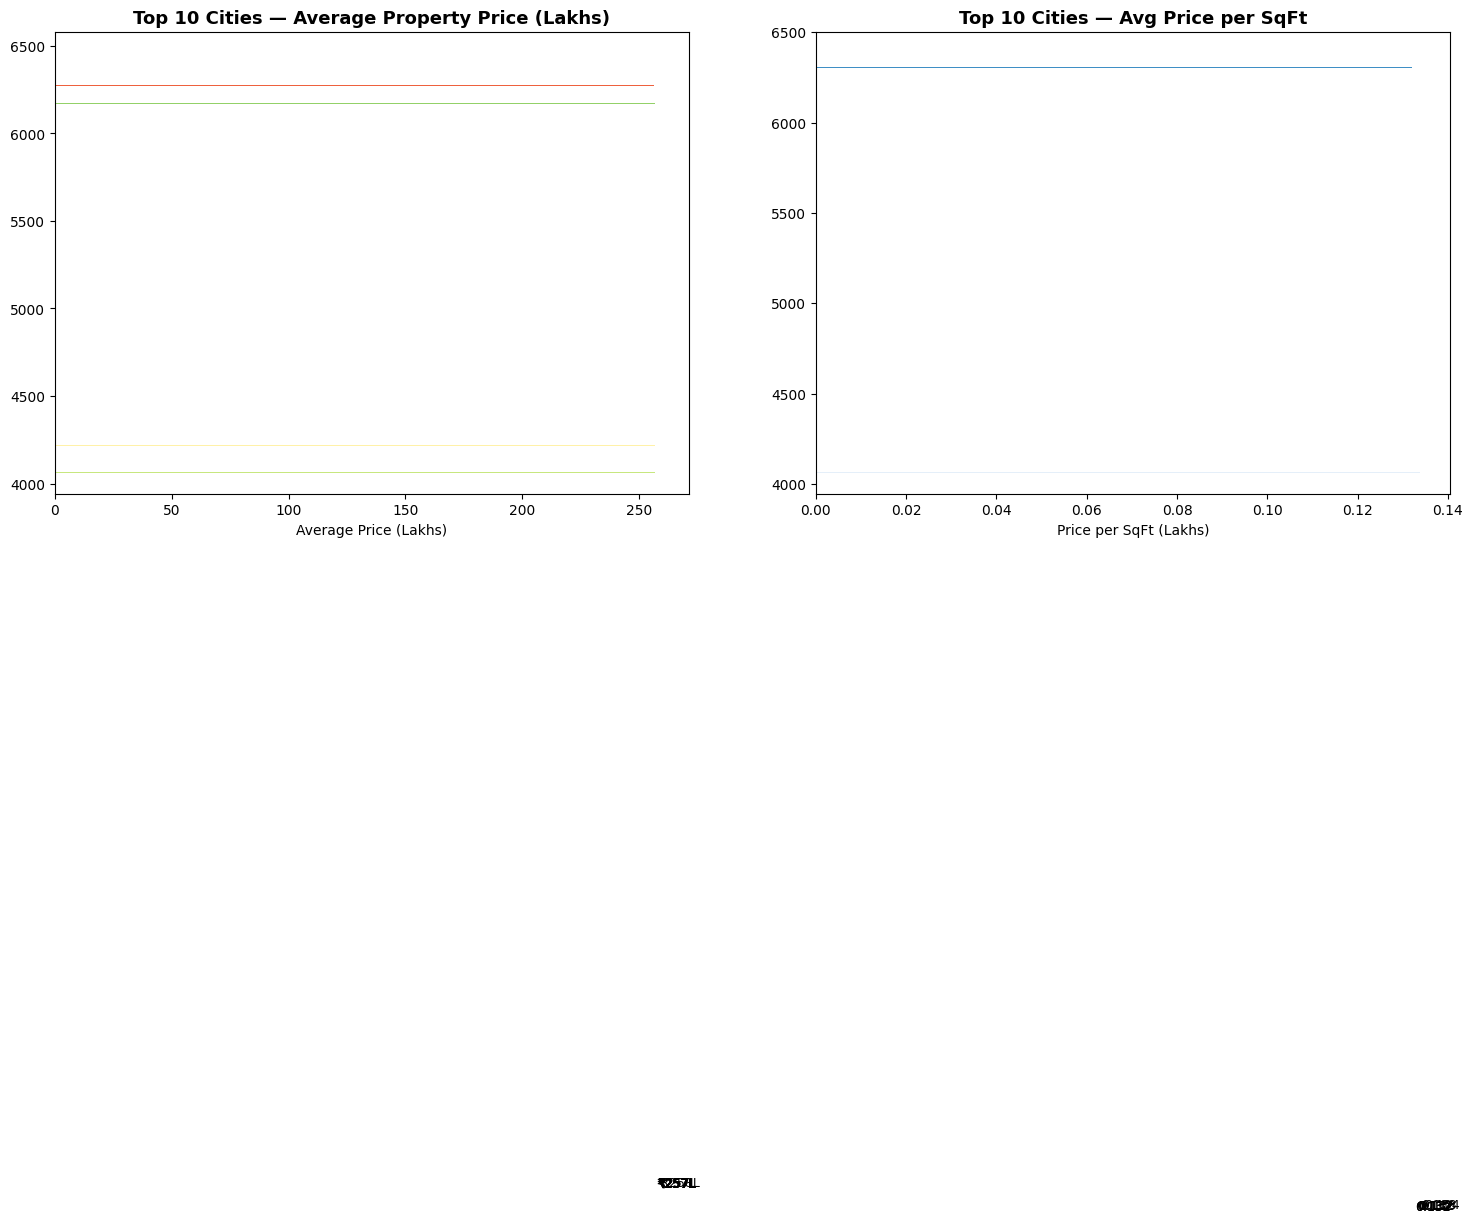

 Saved: 01_price_trends_by_city.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Chart 1: Avg Price by City (Top 10) ──
city_price = (df.groupby('City_Freq')['Price_in_Lakhs']
              .mean().sort_values(ascending=False).head(10))

axes[0].barh(city_price.index[::-1], city_price.values[::-1],
             color=sns.color_palette("RdYlGn", 10))
axes[0].set_title('Top 10 Cities — Average Property Price (Lakhs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Price (Lakhs)')
for i, v in enumerate(city_price.values[::-1]):
    axes[0].text(v + 1, i, f'₹{v:.0f}L', va='center', fontsize=9)

# ── Chart 2: Avg Price per SqFt by City (Top 10) ──
city_ppsf = (df.groupby('City_Freq')['Price_per_SqFt']
             .mean().sort_values(ascending=False).head(10))

axes[1].barh(city_ppsf.index[::-1], city_ppsf.values[::-1],
             color=sns.color_palette("Blues_r", 10))
axes[1].set_title('Top 10 Cities — Avg Price per SqFt', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price per SqFt (Lakhs)')
for i, v in enumerate(city_ppsf.values[::-1]):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig("plots/01_price_trends_by_city.png", dpi=150)
plt.show()
print(" Saved: 01_price_trends_by_city.png")

Price Distribution Across Cities (Boxplot)

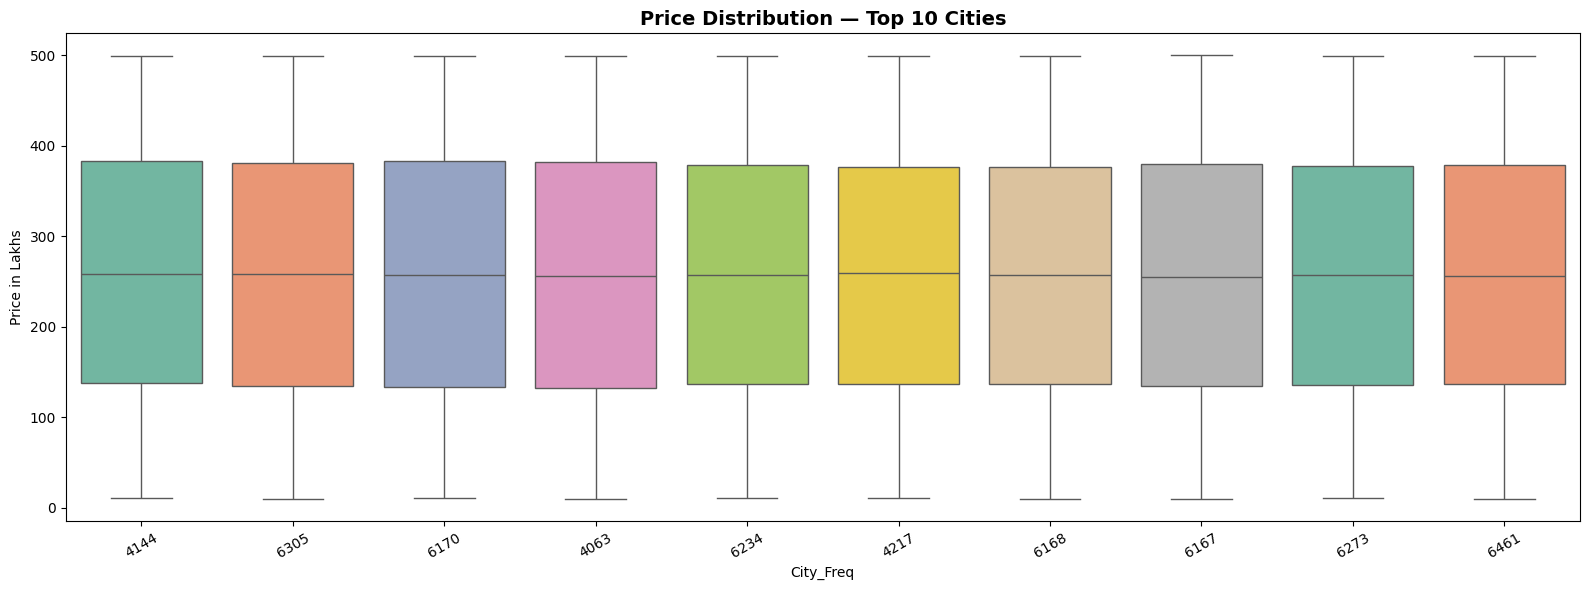

 Saved: 02_price_distribution_cities.png


In [18]:
top10_cities = (df.groupby('City_Freq')['Price_in_Lakhs']
                .mean().sort_values(ascending=False).head(10).index)
df_top = df[df['City_Freq'].isin(top10_cities)]

plt.figure(figsize=(16, 6))
sns.boxplot(data=df_top, x='City_Freq', y='Price_in_Lakhs',
            order=top10_cities,
            palette='Set2')
plt.title('Price Distribution — Top 10 Cities', fontsize=14, fontweight='bold')
plt.xlabel('City_Freq')
plt.ylabel('Price in Lakhs')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plots/02_price_distribution_cities.png", dpi=150)
plt.show()
print(" Saved: 02_price_distribution_cities.png")

City-wise Good Investment Rate

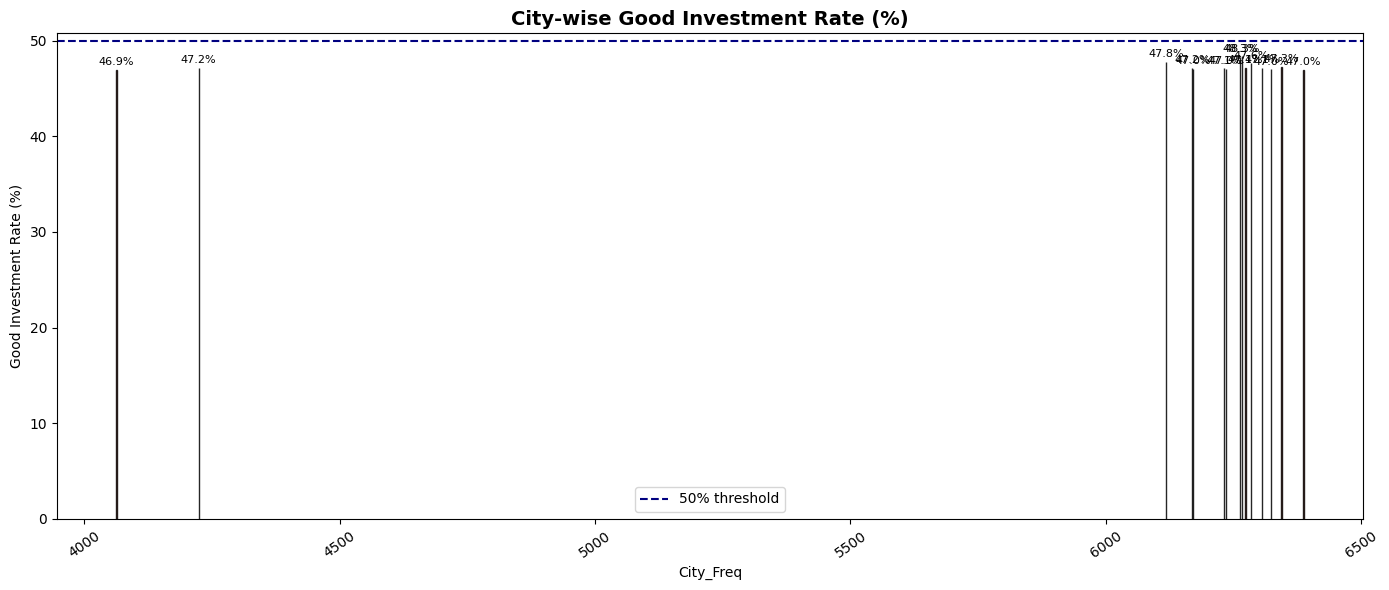

 Saved: 03_city_investment_rate.png


In [19]:
city_invest = (df.groupby('City_Freq')['Good_Investment']
               .mean().sort_values(ascending=False).head(15) * 100)

plt.figure(figsize=(14, 6))
bars = plt.bar(city_invest.index, city_invest.values,
               color=['#2ecc71' if v >= 50 else '#e74c3c' for v in city_invest.values],
               edgecolor='black', alpha=0.85)
plt.axhline(y=50, color='navy', linestyle='--', linewidth=1.5, label='50% threshold')
plt.title('City-wise Good Investment Rate (%)', fontsize=14, fontweight='bold')
plt.xlabel('City_Freq')
plt.ylabel('Good Investment Rate (%)')
plt.xticks(rotation=35)
plt.legend()
for bar, val in zip(bars, city_invest.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5, f'{val:.1f}%',
             ha='center', fontsize=8)
plt.tight_layout()
plt.savefig("plots/03_city_investment_rate.png", dpi=150)
plt.show()
print(" Saved: 03_city_investment_rate.png")

Price Trend by Property Type & City (Heatmap)

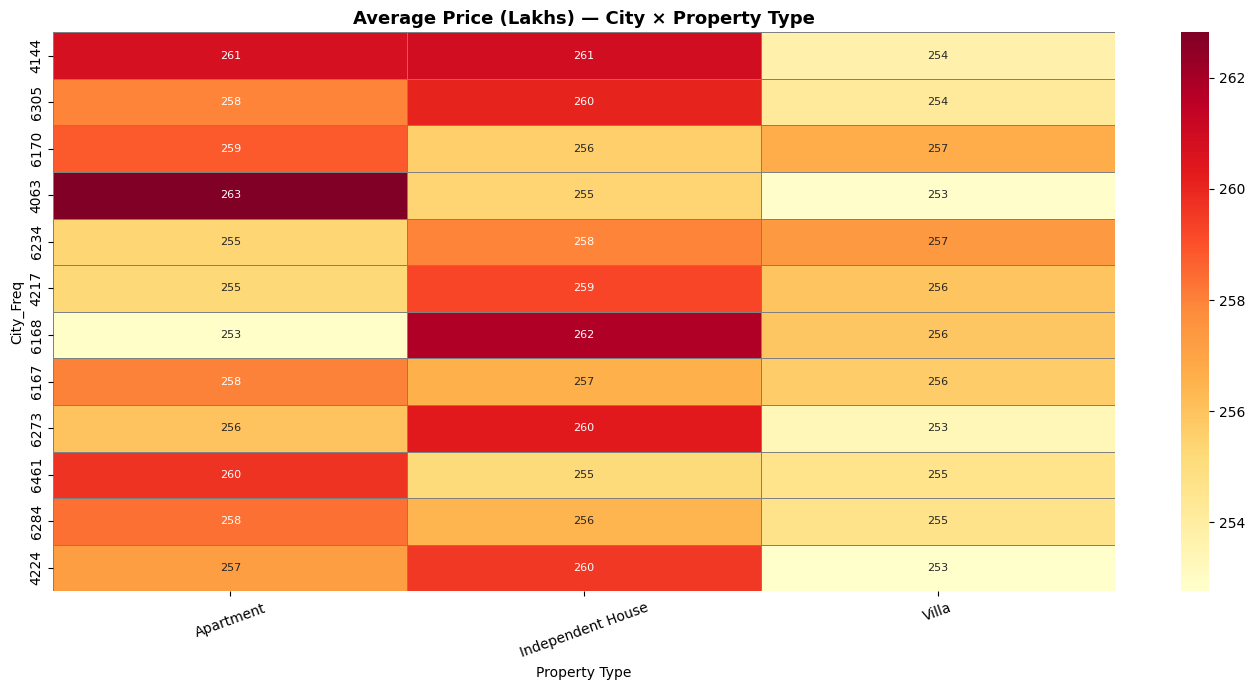

 Saved: 04_city_property_heatmap.png


In [20]:
# To generate the heatmap with property types, we need to reconstruct a temporary 'Property_Type' column
# from the one-hot encoded columns.

# Identify one-hot encoded property type columns
ohe_property_type_cols = [col for col in df.columns if col.startswith('Property_Type_')]

# Create a temporary DataFrame for plotting to avoid modifying the original 'df'
temp_df_for_plot = df.copy()

# Reconstruct the 'Property_Type' column
# Assuming 'Apartment' was the dropped category (common with drop_first=True and alphabetical order)
temp_df_for_plot['Property_Type_Reconstructed'] = 'Apartment' # Default to the assumed dropped category

for col in ohe_property_type_cols:
    # Extract the original property type name (e.g., 'Independent House' from 'Property_Type_Independent House')
    property_name = col.replace('Property_Type_', '')
    # For rows where this OHE column is 1, set the reconstructed type
    temp_df_for_plot.loc[temp_df_for_plot[col] == 1, 'Property_Type_Reconstructed'] = property_name

# Now, use the reconstructed column for the pivot table
pivot = temp_df_for_plot.groupby(['City_Freq', 'Property_Type_Reconstructed'])['Price_in_Lakhs'].mean().unstack()
pivot = pivot.loc[temp_df_for_plot.groupby('City_Freq')['Price_in_Lakhs']
                  .mean().sort_values(ascending=False).head(12).index]

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 8})
plt.title('Average Price (Lakhs) — City × Property Type', fontsize=13, fontweight='bold')
plt.xlabel('Property Type')
plt.ylabel('City_Freq')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("plots/04_city_property_heatmap.png", dpi=150)
plt.show()
print(" Saved: 04_city_property_heatmap.png")

# Correlation: Area vs Investment Return

Size vs Price Scatter

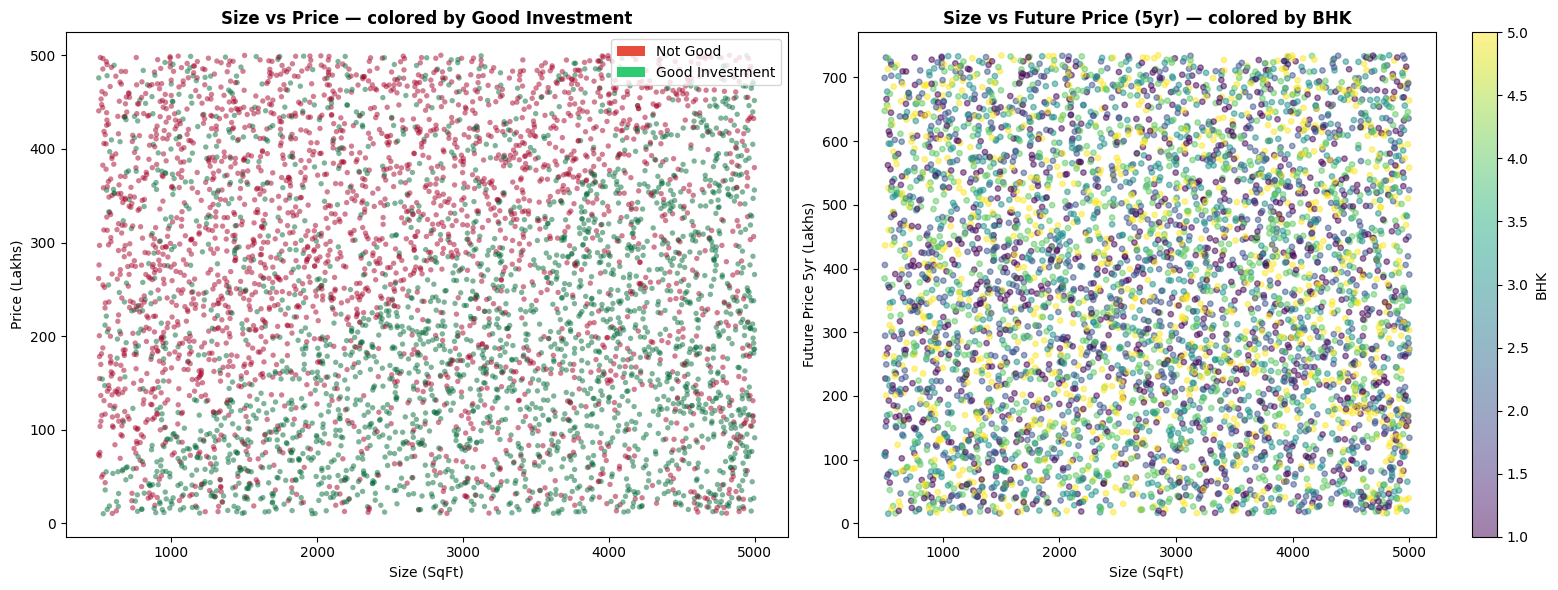

 Saved: 05_size_vs_price_scatter.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sample 5000 for faster plotting
sample = df.sample(5000, random_state=42)

# ── Chart 1: Size vs Price ──
axes[0].scatter(sample['Size_in_SqFt'], sample['Price_in_Lakhs'],
                c=sample['Good_Investment'],
                cmap='RdYlGn', alpha=0.5, edgecolors='none', s=15)
axes[0].set_title('Size vs Price — colored by Good Investment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Size (SqFt)')
axes[0].set_ylabel('Price (Lakhs)')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Not Good'),
                   Patch(facecolor='#2ecc71', label='Good Investment')]
axes[0].legend(handles=legend_elements)

# ── Chart 2: Size vs Future Price ──
axes[1].scatter(sample['Size_in_SqFt'], sample['Future_Price_5yr'],
                c=sample['BHK'], cmap='viridis', alpha=0.5, s=15)
axes[1].set_title('Size vs Future Price (5yr) — colored by BHK', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Size (SqFt)')
axes[1].set_ylabel('Future Price 5yr (Lakhs)')
plt.colorbar(axes[1].collections[0], ax=axes[1], label='BHK')

plt.tight_layout()
plt.savefig("plots/05_size_vs_price_scatter.png", dpi=150)
plt.show()
print(" Saved: 05_size_vs_price_scatter.png")

Correlation Heatmap

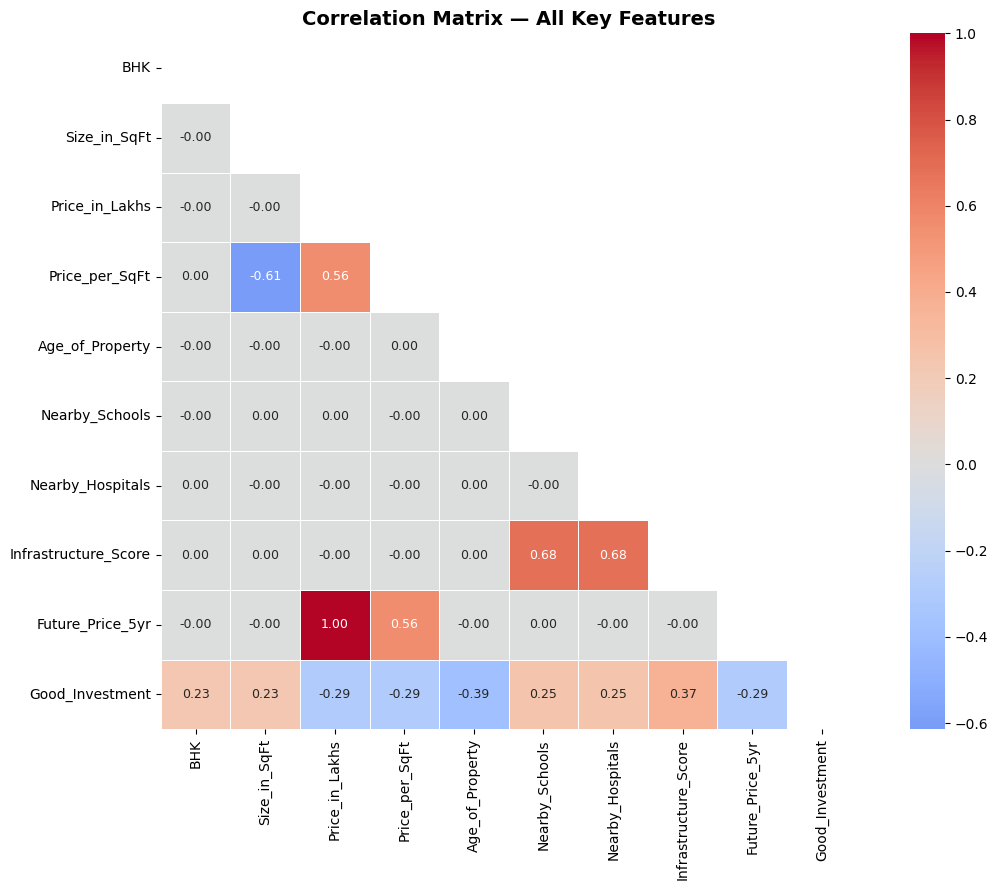

 Saved: 06_correlation_heatmap.png


In [22]:
corr_cols = ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt',
             'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals',
             'Infrastructure_Score', 'Future_Price_5yr', 'Good_Investment']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Matrix — All Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/06_correlation_heatmap.png", dpi=150)
plt.show()
print(" Saved: 06_correlation_heatmap.png")

BHK vs Investment Return

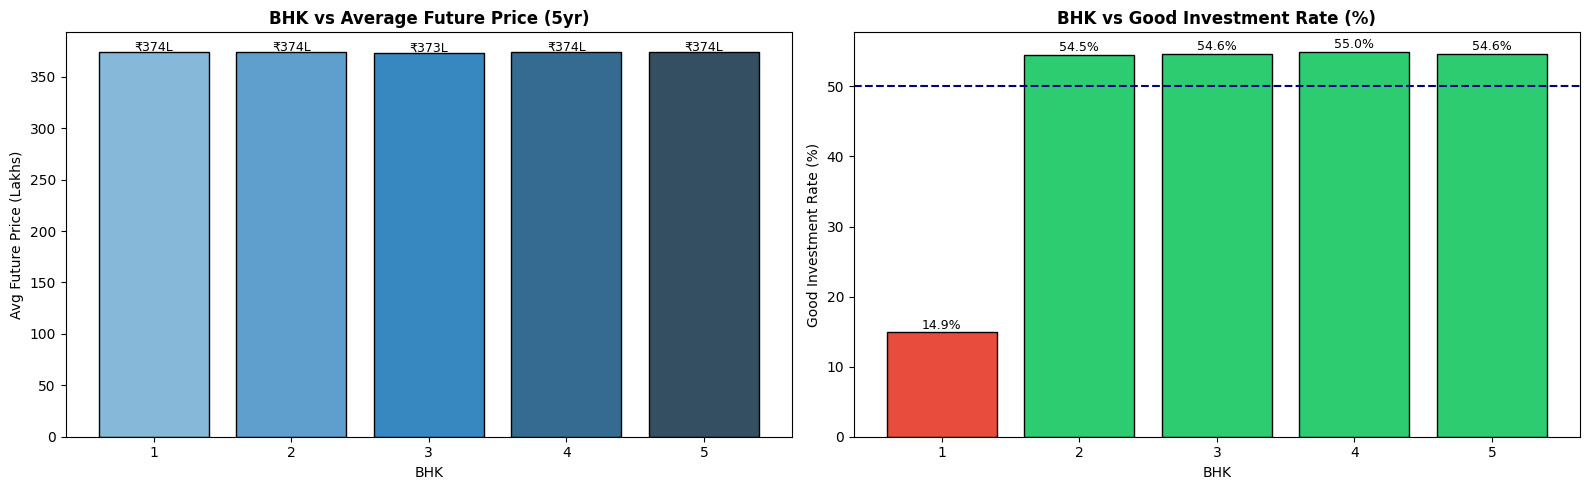

 Saved: 07_bhk_vs_investment.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: BHK vs Avg Future Price ──
bhk_price = df.groupby('BHK')['Future_Price_5yr'].mean()
axes[0].bar(bhk_price.index, bhk_price.values,
            color=sns.color_palette("Blues_d", len(bhk_price)),
            edgecolor='black')
axes[0].set_title('BHK vs Average Future Price (5yr)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BHK')
axes[0].set_ylabel('Avg Future Price (Lakhs)')
for i, v in enumerate(bhk_price.values):
    axes[0].text(bhk_price.index[i], v + 1, f'₹{v:.0f}L', ha='center', fontsize=9)

# ── Chart 2: BHK vs Good Investment Rate ──
bhk_invest = df.groupby('BHK')['Good_Investment'].mean() * 100
axes[1].bar(bhk_invest.index, bhk_invest.values,
            color=['#2ecc71' if v >= 50 else '#e74c3c' for v in bhk_invest.values],
            edgecolor='black')
axes[1].set_title('BHK vs Good Investment Rate (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BHK')
axes[1].set_ylabel('Good Investment Rate (%)')
axes[1].axhline(y=50, color='navy', linestyle='--', linewidth=1.5)
for i, v in enumerate(bhk_invest.values):
    axes[1].text(bhk_invest.index[i], v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("plots/07_bhk_vs_investment.png", dpi=150)
plt.show()
print(" Saved: 07_bhk_vs_investment.png")

# Impact of crime rate on good investment classification


Security vs Good Investment

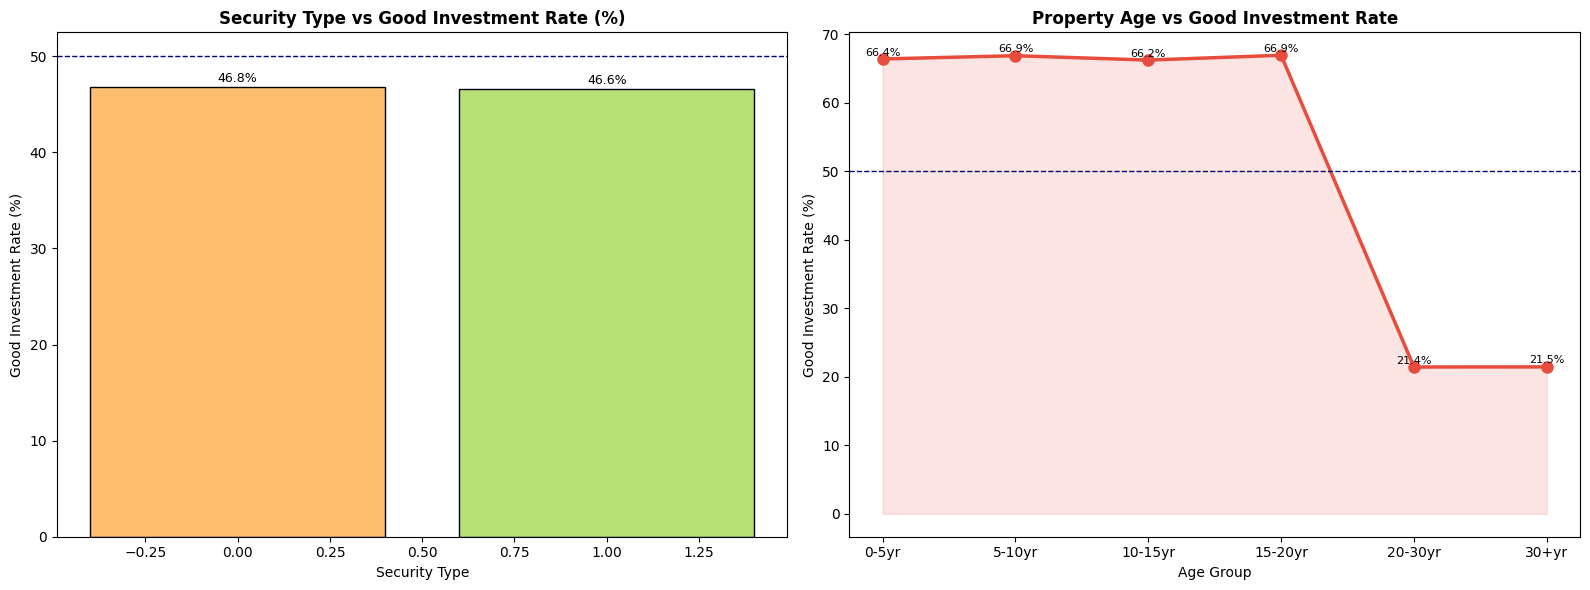

 Saved: 08_security_age_investment.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Chart 1: Security type vs Good Investment Rate ──
sec_invest = (df.groupby('Security')['Good_Investment']
              .mean().sort_values(ascending=False) * 100)
axes[0].bar(sec_invest.index, sec_invest.values,
            color=sns.color_palette("RdYlGn", len(sec_invest)),
            edgecolor='black')
axes[0].set_title('Security Type vs Good Investment Rate (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Security Type')
axes[0].set_ylabel('Good Investment Rate (%)')
axes[0].axhline(y=50, color='navy', linestyle='--', linewidth=1)
for i, (idx, v) in enumerate(sec_invest.items()):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# ── Chart 2: Age of Property vs Good Investment (binned) ──
df['Age_Group'] = pd.cut(df['Age_of_Property'],
                              bins=[0, 5, 10, 15, 20, 30, 100],
                              labels=['0-5yr', '5-10yr', '10-15yr',
                                      '15-20yr', '20-30yr', '30+yr'])
age_invest = df.groupby('Age_Group', observed=True)['Good_Investment'].mean() * 100
axes[1].plot(age_invest.index.astype(str), age_invest.values,
             marker='o', color='#e74c3c', linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(age_invest)), age_invest.values,
                     alpha=0.15, color='#e74c3c')
axes[1].set_title('Property Age vs Good Investment Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Good Investment Rate (%)')
axes[1].axhline(y=50, color='navy', linestyle='--', linewidth=1)
for i, v in enumerate(age_invest.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("plots/08_security_age_investment.png", dpi=150)
plt.show()
print(" Saved: 08_security_age_investment.png")

Availability Status vs Investment Risk

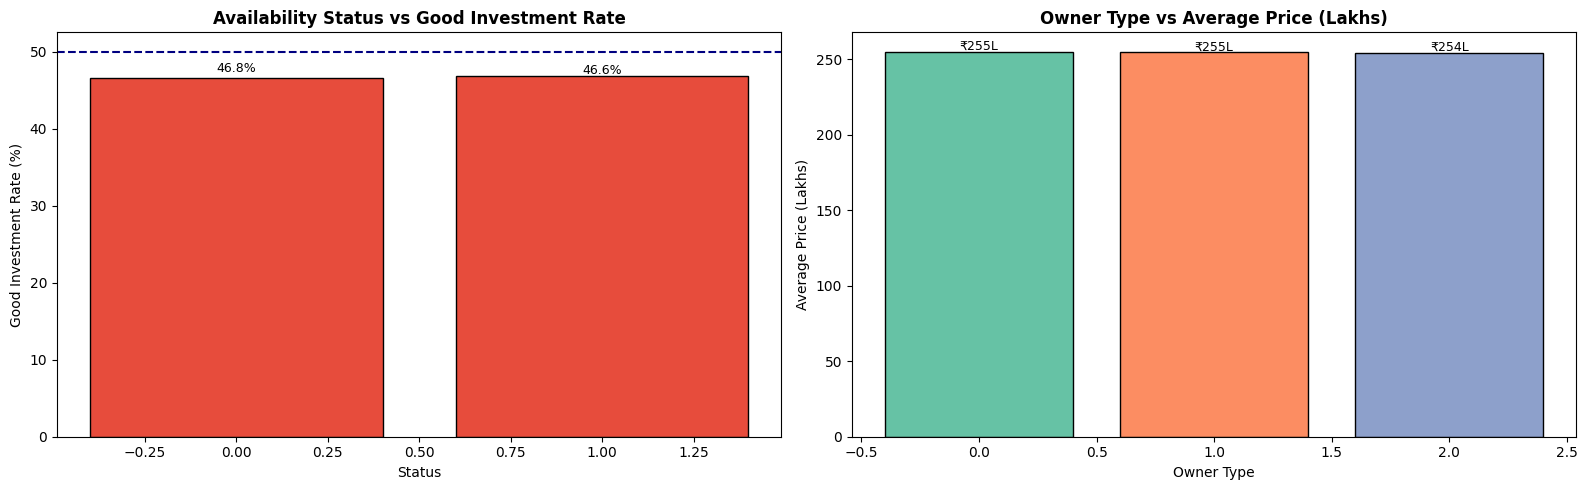

 Saved: 09_availability_owner_analysis.png


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Availability vs Good Investment ──
avail_invest = (df.groupby('Availability_Status')['Good_Investment']
                .mean().sort_values(ascending=False) * 100)
colors = ['#2ecc71' if v >= 50 else '#e74c3c' for v in avail_invest.values]
axes[0].bar(avail_invest.index, avail_invest.values, color=colors, edgecolor='black')
axes[0].set_title('Availability Status vs Good Investment Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Good Investment Rate (%)')
axes[0].axhline(y=50, linestyle='--', color='navy')
for i, v in enumerate(avail_invest.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# ── Chart 2: Owner Type vs Avg Price ──
owner_price = df.groupby('Owner_Type')['Price_in_Lakhs'].mean().sort_values(ascending=False)
axes[1].bar(owner_price.index, owner_price.values,
            color=sns.color_palette("Set2", len(owner_price)), edgecolor='black')
axes[1].set_title('Owner Type vs Average Price (Lakhs)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Owner Type')
axes[1].set_ylabel('Average Price (Lakhs)')
for i, v in enumerate(owner_price.values):
    axes[1].text(i, v + 1, f'₹{v:.0f}L', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("plots/09_availability_owner_analysis.png", dpi=150)
plt.show()
print(" Saved: 09_availability_owner_analysis.png")

# Relationship between infrastructure score and resale value

Infrastructure Score vs Future Price

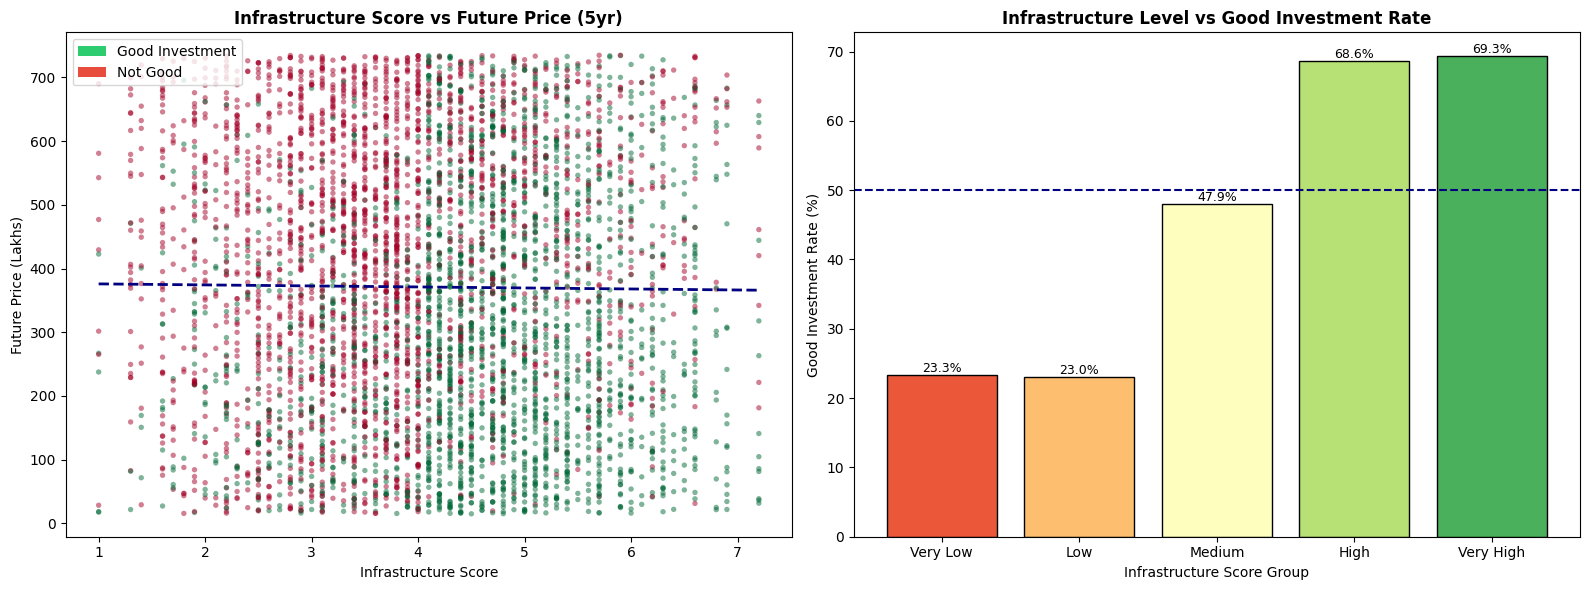

 Saved: 10_infrastructure_vs_resale.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sample = df.sample(5000, random_state=42)

# ── Chart 1: Infrastructure Score vs Future Price ──
axes[0].scatter(sample['Infrastructure_Score'], sample['Future_Price_5yr'],
                c=sample['Good_Investment'], cmap='RdYlGn',
                alpha=0.5, s=15, edgecolors='none')
z = np.polyfit(sample['Infrastructure_Score'], sample['Future_Price_5yr'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['Infrastructure_Score'].min(),
                     sample['Infrastructure_Score'].max(), 100)
axes[0].plot(x_line, p(x_line), 'navy', linewidth=2, linestyle='--', label='Trend')
axes[0].set_title('Infrastructure Score vs Future Price (5yr)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Infrastructure Score')
axes[0].set_ylabel('Future Price (Lakhs)')
axes[0].legend()
from matplotlib.patches import Patch
legend_e = [Patch(facecolor='#2ecc71', label='Good Investment'),
            Patch(facecolor='#e74c3c', label='Not Good')]
axes[0].legend(handles=legend_e, loc='upper left')

# ── Chart 2: Infrastructure Score Bins vs Good Investment ──
df['Infra_Group'] = pd.cut(df['Infrastructure_Score'],
                                bins=5,
                                labels=['Very Low','Low','Medium','High','Very High'])
infra_invest = df.groupby('Infra_Group', observed=True)['Good_Investment'].mean() * 100
axes[1].bar(infra_invest.index.astype(str), infra_invest.values,
            color=sns.color_palette("RdYlGn", 5), edgecolor='black')
axes[1].set_title('Infrastructure Level vs Good Investment Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Infrastructure Score Group')
axes[1].set_ylabel('Good Investment Rate (%)')
axes[1].axhline(y=50, color='navy', linestyle='--', linewidth=1.5)
for i, v in enumerate(infra_invest.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("plots/10_infrastructure_vs_resale.png", dpi=150)
plt.show()
print(" Saved: 10_infrastructure_vs_resale.png")

Schools & Hospitals vs Resale Value

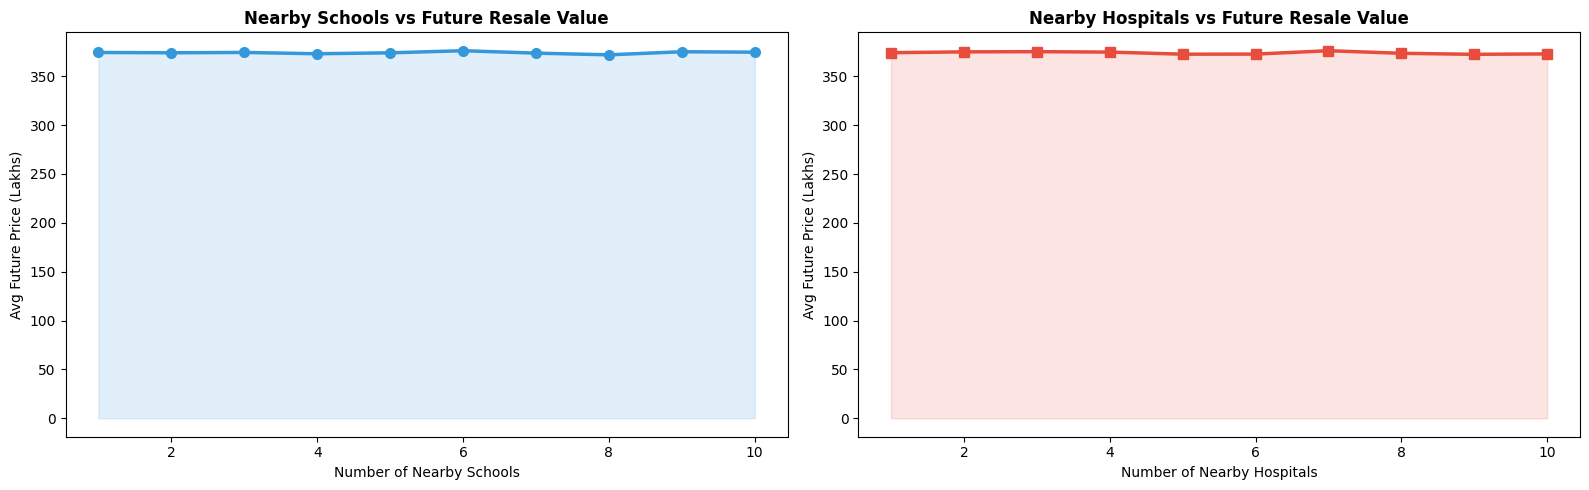

 Saved: 11_amenities_vs_resale.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Chart 1: Nearby Schools vs Future Price ──
school_price = df.groupby('Nearby_Schools')['Future_Price_5yr'].mean()
axes[0].plot(school_price.index, school_price.values,
             marker='o', color='#3498db', linewidth=2.5, markersize=7)
axes[0].fill_between(school_price.index, school_price.values, alpha=0.15, color='#3498db')
axes[0].set_title('Nearby Schools vs Future Resale Value', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Nearby Schools')
axes[0].set_ylabel('Avg Future Price (Lakhs)')

# ── Chart 2: Nearby Hospitals vs Future Price ──
hosp_price = df.groupby('Nearby_Hospitals')['Future_Price_5yr'].mean()
axes[1].plot(hosp_price.index, hosp_price.values,
             marker='s', color='#e74c3c', linewidth=2.5, markersize=7)
axes[1].fill_between(hosp_price.index, hosp_price.values, alpha=0.15, color='#e74c3c')
axes[1].set_title('Nearby Hospitals vs Future Resale Value', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Nearby Hospitals')
axes[1].set_ylabel('Avg Future Price (Lakhs)')

plt.tight_layout()
plt.savefig("plots/11_amenities_vs_resale.png", dpi=150)
plt.show()
print(" Saved: 11_amenities_vs_resale.png")

Public Transport vs Price & Investment

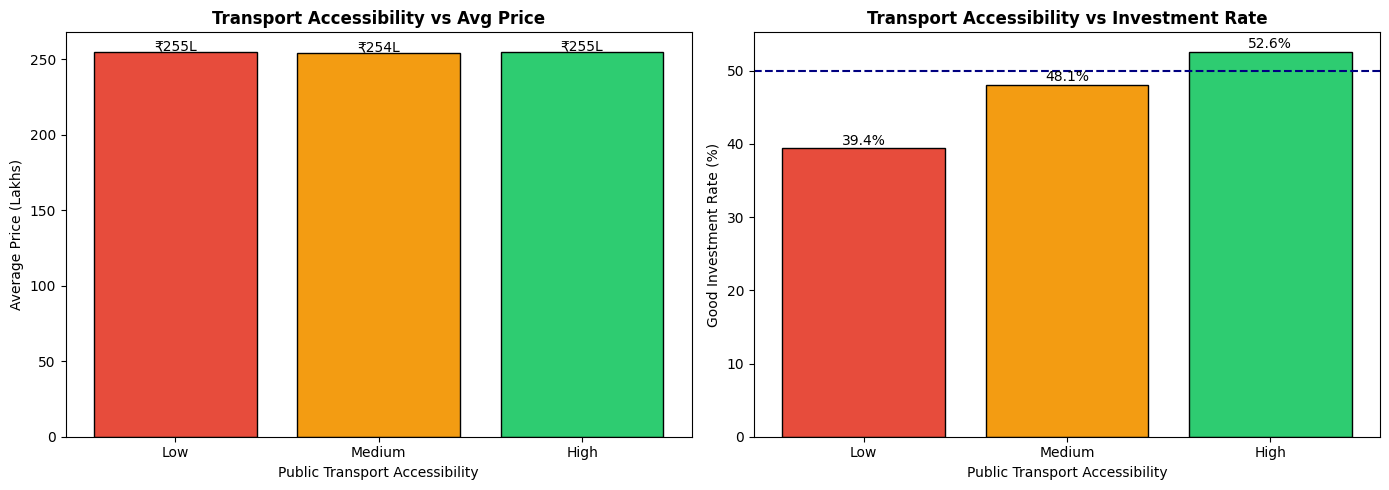

 Saved: 12_transport_vs_investment.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Transport Accessibility vs Avg Price ──
transport_price = df.groupby('Public_Transport_Accessibility')['Price_in_Lakhs'].mean()
order = ['Low', 'Medium', 'High']
transport_price = transport_price.reindex(order)
axes[0].bar(transport_price.index, transport_price.values,
            color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
axes[0].set_title('Transport Accessibility vs Avg Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Public Transport Accessibility')
axes[0].set_ylabel('Average Price (Lakhs)')
for i, v in enumerate(transport_price.values):
    axes[0].text(i, v + 1, f'₹{v:.0f}L', ha='center', fontsize=10)

# ── Chart 2: Transport Accessibility vs Good Investment ──
transport_invest = (df.groupby('Public_Transport_Accessibility')['Good_Investment']
                    .mean().reindex(order) * 100)
axes[1].bar(transport_invest.index, transport_invest.values,
            color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
axes[1].set_title('Transport Accessibility vs Investment Rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Public Transport Accessibility')
axes[1].set_ylabel('Good Investment Rate (%)')
axes[1].axhline(y=50, color='navy', linestyle='--')
for i, v in enumerate(transport_invest.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig("plots/12_transport_vs_investment.png", dpi=150)
plt.show()
print(" Saved: 12_transport_vs_investment.png")

# Model Building

 Load Processed Data & Define Features


In [29]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report, mean_squared_error,
                              mean_absolute_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor
import joblib, math, warnings
warnings.filterwarnings('ignore')

# Load processed data
df_model = pd.read_csv("data/processed_data.csv")

print(" Shape:", df_model.shape)
print(" Columns:", df_model.columns.tolist())

 Shape: (250000, 25)
 Columns: ['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status', 'Good_Investment', 'Future_Price_5yr']


Select Features & Split Data

In [30]:
# ── Select feature columns ──
drop_cols = ['ID', 'Year_Built', 'Good_Investment',
             'Future_Price_5yr', 'Rule_Score',
             'Price_Category', 'Age_Group', 'Infra_Group']

# Classification features (from df_model)
feature_cols = [col for col in df_model.columns
                if col not in drop_cols
                and df_model[col].dtype != 'object']

# Regression features (from df — has engineered features)
reg_feature_cols = ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt',
                    'Floor_No', 'Total_Floors', 'Age_of_Property',
                    'Nearby_Schools', 'Nearby_Hospitals',
                    'Infrastructure_Score', 'School_Density_Score',
                    'Hospital_Density_Score', 'Floor_Ratio', 'Value_Score']

reg_feature_cols = [c for c in reg_feature_cols if c in df.columns]

print(f" Classification Features : {len(feature_cols)}")
print(f" Regression Features     : {len(reg_feature_cols)}")

print(f" Total Features: {len(feature_cols)}")
print(feature_cols)

X = df_model[feature_cols]
y_clf = df_model['Good_Investment']       # Classification target
y_reg = df_model['Future_Price_5yr']      # Regression target

# ── Train Test Split ──
X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Regression uses df (has all engineered features)
X_reg = df[reg_feature_cols]
y_reg  = df['Future_Price_5yr']

X_reg_train, X_reg_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print(f"\n Train size : {X_train.shape}")
print(f" Test size  : {X_test.shape}")
print(f" Class Balance (train): {yc_train.value_counts().to_dict()}")

 Classification Features : 9
 Regression Features     : 14
 Total Features: 9
['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']

 Train size : (200000, 9)
 Test size  : (50000, 9)
 Class Balance (train): {0: 106592, 1: 93408}


# 1-Classification Model (Good Investment)

Train & Compare Classification Models

In [31]:
clf_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'             : XGBClassifier(n_estimators=100, random_state=42,
                                          eval_metric='logloss', verbosity=0)
}

clf_results = {}

print("=" * 55)
print("       CLASSIFICATION MODEL COMPARISON")
print("=" * 55)

for name, model in clf_models.items():
    model.fit(X_train, yc_train)
    preds    = model.predict(X_test)
    acc      = accuracy_score(yc_test, preds)
    f1       = f1_score(yc_test, preds)
    cv_score = cross_val_score(model, X_train, yc_train,
                               cv=3, scoring='accuracy').mean()
    clf_results[name] = {'Accuracy': acc, 'F1 Score': f1, 'CV Score': cv_score}
    print(f"\n {name}")
    print(f"   Accuracy : {acc*100:.2f}%")
    print(f"   F1 Score : {f1:.4f}")
    print(f"   CV Score : {cv_score*100:.2f}%")

print("\n" + "=" * 55)

       CLASSIFICATION MODEL COMPARISON

 Logistic Regression
   Accuracy : 82.00%
   F1 Score : 0.8054
   CV Score : 82.38%

 Random Forest
   Accuracy : 95.21%
   F1 Score : 0.9493
   CV Score : 95.19%

 XGBoost
   Accuracy : 95.44%
   F1 Score : 0.9518
   CV Score : 95.33%



Best Classification Model + Confusion Matrix

 Best Classification Model: XGBoost


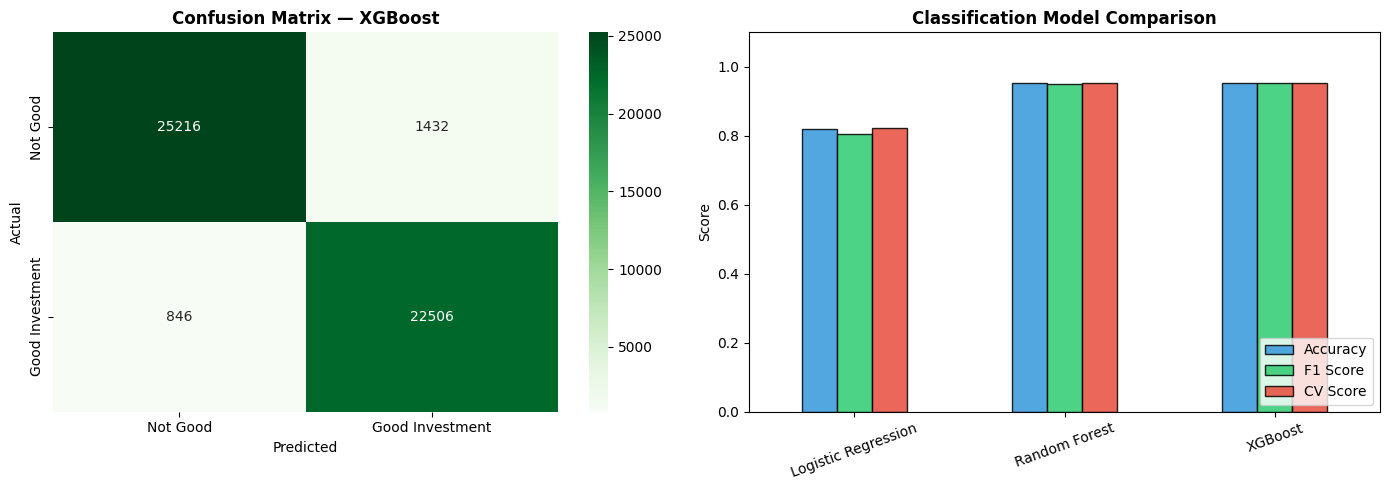


 Classification Report:
                 precision    recall  f1-score   support

       Not Good       0.97      0.95      0.96     26648
Good Investment       0.94      0.96      0.95     23352

       accuracy                           0.95     50000
      macro avg       0.95      0.96      0.95     50000
   weighted avg       0.95      0.95      0.95     50000



In [32]:
# ── Pick Best Model ──
best_clf_name = max(clf_results, key=lambda x: clf_results[x]['F1 Score'])
best_clf      = clf_models[best_clf_name]
print(f" Best Classification Model: {best_clf_name}")

# ── Confusion Matrix ──
preds_best = best_clf.predict(X_test)
cm = confusion_matrix(yc_test, preds_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Good', 'Good Investment'],
            yticklabels=['Not Good', 'Good Investment'],
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix — {best_clf_name}', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Model Comparison Bar Chart
metrics_df = pd.DataFrame(clf_results).T
metrics_df[['Accuracy', 'F1 Score', 'CV Score']].plot(
    kind='bar', ax=axes[1],
    color=['#3498db','#2ecc71','#e74c3c'],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Classification Model Comparison', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.1)
axes[1].legend(loc='lower right')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.savefig("plots/13_classification_results.png", dpi=150)
plt.show()

# ── Full Report ──
print("\n Classification Report:")
print(classification_report(yc_test, preds_best,
      target_names=['Not Good', 'Good Investment']))

Feature Importance (Classification)

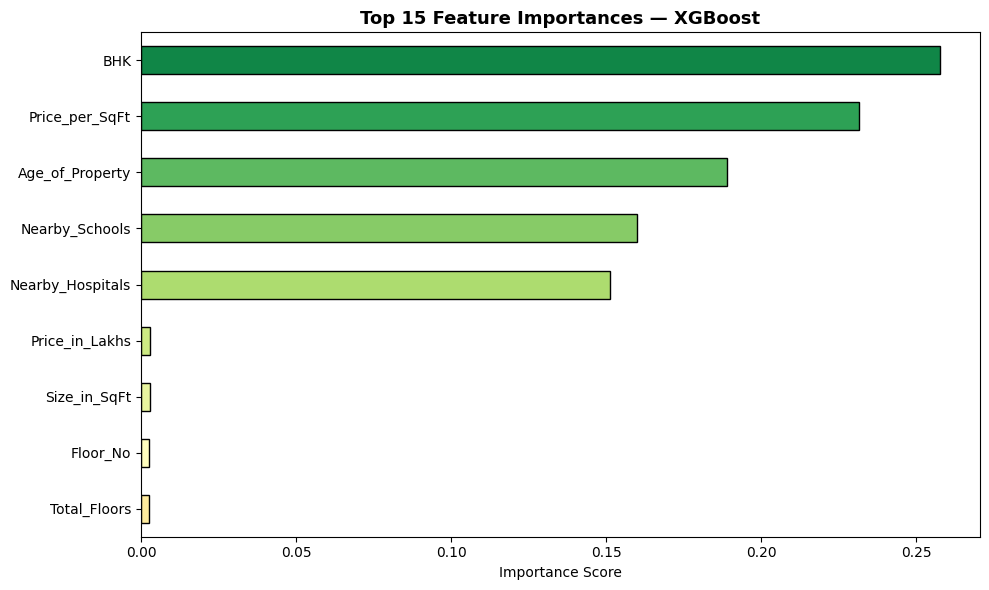

 Saved: 14_feature_importance_clf.png


In [33]:
if hasattr(best_clf, 'feature_importances_'):
    feat_imp = pd.Series(best_clf.feature_importances_,
                         index=feature_cols).sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color=sns.color_palette("RdYlGn_r", 15),
                  edgecolor='black')
    plt.gca().invert_yaxis()
    plt.title(f'Top 15 Feature Importances — {best_clf_name}',
              fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig("plots/14_feature_importance_clf.png", dpi=150)
    plt.show()
    print(" Saved: 14_feature_importance_clf.png")

## 2-Regression Model (Future Price)

Train & Compare Regression Models

In [34]:
reg_models = {
    'Linear Regression' : LinearRegression(),
    'Random Forest'     : RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost'           : XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

reg_results = {}

print("=" * 55)
print("         REGRESSION MODEL COMPARISON")
print("=" * 55)

for name, model in reg_models.items():
    model.fit(X_reg_train, yr_train)
    preds = model.predict(X_reg_test)
    rmse  = math.sqrt(mean_squared_error(yr_test, preds))
    mae   = mean_absolute_error(yr_test, preds)
    r2    = r2_score(yr_test, preds)
    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"\n {name}")
    print(f"   RMSE : {rmse:.4f}")
    print(f"   MAE  : {mae:.4f}")
    print(f"   R²   : {r2:.4f}")

print("\n" + "=" * 55)

         REGRESSION MODEL COMPARISON

 Linear Regression
   RMSE : 0.0000
   MAE  : 0.0000
   R²   : 1.0000

 Random Forest
   RMSE : 0.0032
   MAE  : 0.0020
   R²   : 1.0000

 XGBoost
   RMSE : 0.8199
   MAE  : 0.7072
   R²   : 1.0000



Best Regression Model + Actual vs Predicted

 Best Regression Model: Linear Regression


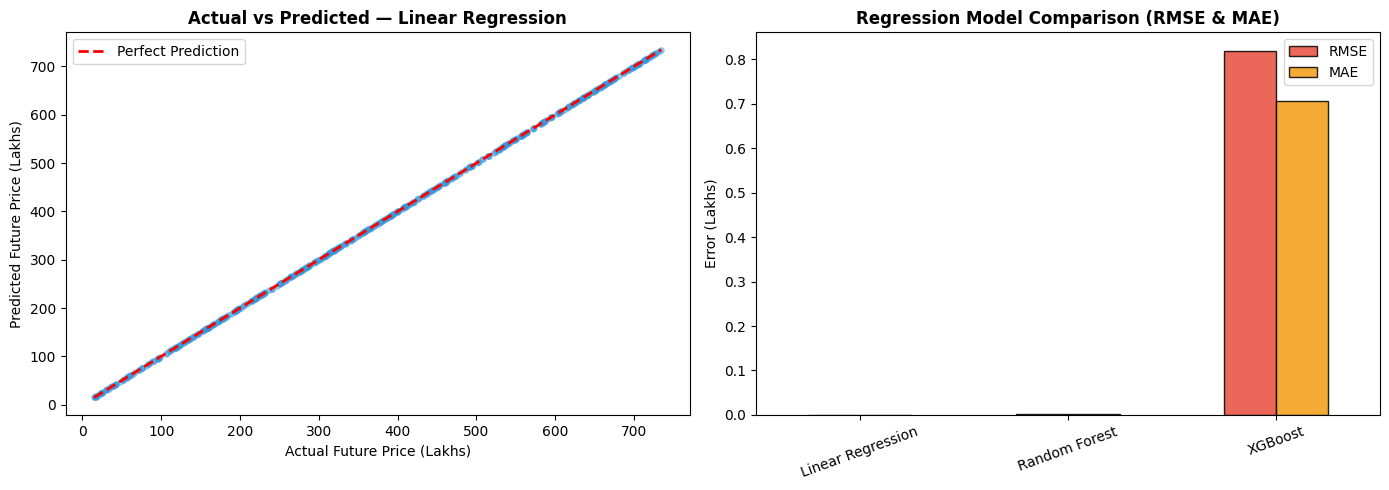


 Best Model Metrics:
   RMSE : 0.0000
   MAE  : 0.0000
   R²   : 1.0000


In [35]:
# ── Pick Best Model ──
best_reg_name = min(reg_results, key=lambda x: reg_results[x]['RMSE'])
best_reg      = reg_models[best_reg_name]
print(f" Best Regression Model: {best_reg_name}")

preds_reg = best_reg.predict(X_reg_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Actual vs Predicted ──
sample_idx = np.random.choice(len(yr_test), 500, replace=False)
axes[0].scatter(yr_test.iloc[sample_idx], preds_reg[sample_idx],
                alpha=0.4, color='#3498db', s=15)
min_val = min(yr_test.min(), preds_reg.min())
max_val = max(yr_test.max(), preds_reg.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted — {best_reg_name}', fontweight='bold')
axes[0].set_xlabel('Actual Future Price (Lakhs)')
axes[0].set_ylabel('Predicted Future Price (Lakhs)')
axes[0].legend()

# ── Regression Metrics Comparison ──
reg_df = pd.DataFrame(reg_results).T
reg_df[['RMSE', 'MAE']].plot(kind='bar', ax=axes[1],
    color=['#e74c3c','#f39c12'], edgecolor='black', alpha=0.85)
axes[1].set_title('Regression Model Comparison (RMSE & MAE)', fontweight='bold')
axes[1].set_ylabel('Error (Lakhs)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20)

plt.tight_layout()
plt.savefig("plots/15_regression_results.png", dpi=150)
plt.show()

print(f"\n Best Model Metrics:")
print(f"   RMSE : {reg_results[best_reg_name]['RMSE']:.4f}")
print(f"   MAE  : {reg_results[best_reg_name]['MAE']:.4f}")
print(f"   R²   : {reg_results[best_reg_name]['R2']:.4f}")

In [36]:
# ── Save Models ──
joblib.dump(best_clf,         "models/clf_model.pkl")
joblib.dump(best_reg,         "models/reg_model.pkl")
joblib.dump(feature_cols,     "models/clf_feature_cols.pkl")
joblib.dump(reg_feature_cols, "models/reg_feature_cols.pkl")
joblib.dump(scaler,           "models/scaler.pkl")

print(" All models saved!")
print(f"   clf_model.pkl       → {best_clf_name}")
print(f"   reg_model.pkl       → {best_reg_name}")
print(f"   clf_feature_cols    → {len(feature_cols)} features")
print(f"   reg_feature_cols    → {len(reg_feature_cols)} features")

 All models saved!
   clf_model.pkl       → XGBoost
   reg_model.pkl       → Linear Regression
   clf_feature_cols    → 9 features
   reg_feature_cols    → 14 features


# 3-MLflow Tracking

Log All Models to MLflow

In [37]:
!pip install mlflow -q
import mlflow
import mlflow.sklearn

mlflow.set_experiment("Real_Estate_Investment_Advisor")

# ── Log Classification ──
with mlflow.start_run(run_name=f"CLF_{best_clf_name}"):
    preds_c = best_clf.predict(X_test)
    mlflow.log_param("model_type",  "Classification")
    mlflow.log_param("model_name",  best_clf_name)
    mlflow.log_param("train_size",  X_train.shape[0])
    mlflow.log_param("n_features",  len(feature_cols))
    mlflow.log_metric("accuracy",   accuracy_score(yc_test, preds_c))
    mlflow.log_metric("f1_score",   f1_score(yc_test, preds_c))
    mlflow.sklearn.log_model(sk_model=best_clf,name="clf_model")
    print(f" Classification logged: {best_clf_name}")

# ── Log Regression ──  ← FIXED: uses X_reg_train/X_reg_test
with mlflow.start_run(run_name=f"REG_{best_reg_name}"):
    preds_r = best_reg.predict(X_reg_test)   # ← fixed
    mlflow.log_param("model_type",  "Regression")
    mlflow.log_param("model_name",  best_reg_name)
    mlflow.log_param("train_size",  X_reg_train.shape[0])
    mlflow.log_param("n_features",  len(reg_feature_cols))
    mlflow.log_metric("rmse",  math.sqrt(mean_squared_error(yr_test, preds_r)))
    mlflow.log_metric("mae",   mean_absolute_error(yr_test, preds_r))
    mlflow.log_metric("r2",    r2_score(yr_test, preds_r))
    mlflow.sklearn.log_model(sk_model=best_reg, name="reg_model")
    print(f" Regression logged: {best_reg_name}")

print("\n MLflow tracking complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

2026/04/18 09:08:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Classification logged: XGBoost


2026/04/18 09:08:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Regression logged: Linear Regression

 MLflow tracking complete!


In [38]:
# Check what scaler was trained on
scaler = joblib.load("models/scaler.pkl")
print("Scaler feature names:", scaler.feature_names_in_)
print("Scaler mean values:", scaler.mean_)

Scaler feature names: ['BHK' 'Size_in_SqFt' 'Price_in_Lakhs' 'Price_per_SqFt' 'Floor_No'
 'Total_Floors' 'Age_of_Property' 'Nearby_Schools' 'Nearby_Hospitals']
Scaler mean values: [2.99939600e+00 2.74981322e+03 2.54586854e+02 1.30596800e-01
 1.49668000e+01 1.55030040e+01 1.84799880e+01 5.49986000e+00
 5.49801600e+00]


# Streamlit App

Create the Full Streamlit App

In [39]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Page Config ──
st.set_page_config(
    page_title="Real Estate Investment Advisor",
    page_icon="🏠",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Custom CSS ──
st.markdown("""
<style>
    .main-header {
        background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460);
        padding: 25px; border-radius: 12px;
        text-align: center; margin-bottom: 20px;
    }
    .main-header h1 { color: #e94560; font-size: 2.2rem; margin: 0; }
    .main-header p  { color: #a8b2d8; font-size: 1rem; margin: 5px 0 0; }
    .good-box {
        background: linear-gradient(135deg, #0f9b58, #00c851);
        padding: 20px; border-radius: 12px;
        text-align: center; color: white;
    }
    .bad-box {
        background: linear-gradient(135deg, #c0392b, #e74c3c);
        padding: 20px; border-radius: 12px;
        text-align: center; color: white;
    }
</style>
""", unsafe_allow_html=True)

# ── Load Models ──
@st.cache_resource
def load_models():
    clf_model    = joblib.load("models/clf_model.pkl")
    reg_model    = joblib.load("models/reg_model.pkl")
    clf_features = joblib.load("models/clf_feature_cols.pkl")
    reg_features = joblib.load("models/reg_feature_cols.pkl")
    scaler       = joblib.load("models/scaler.pkl")
    return clf_model, reg_model, clf_features, reg_features, scaler

@st.cache_data
def load_data():
    df = pd.read_csv("data/india_housing_prices.csv")
    df["Age_of_Property"]   = 2025 - df["Year_Built"]
    df["Future_Price_5yr"]  = df["Price_in_Lakhs"] * (1.08 ** 5)
    t_map = {"Low":1,"Medium":2,"High":3}
    df["Transport_Num"]     = df["Public_Transport_Accessibility"].map(t_map)
    df["Infrastructure_Score"] = (
        df["Nearby_Schools"]   * 0.3 +
        df["Nearby_Hospitals"] * 0.3 +
        df["Transport_Num"]    * 0.4
    ).round(2)
    city_med = df.groupby("City")["Price_per_SqFt"].transform("median")
    r1 = df["Price_per_SqFt"] <= city_med
    r2 = df["BHK"] >= 2
    r3 = df["Infrastructure_Score"] >= df["Infrastructure_Score"].median()
    r4 = df["Age_of_Property"] <= 20
    appr = (df["Future_Price_5yr"] - df["Price_in_Lakhs"]) / df["Price_in_Lakhs"]
    r5 = appr >= 0.40
    df["Good_Investment"] = (
        (r1.astype(int)+r2.astype(int)+r3.astype(int)+
         r4.astype(int)+r5.astype(int)) >= 4
    ).astype(int)
    return df

clf_model, reg_model, clf_features, reg_features, scaler = load_models()
df_raw = load_data()

# ── Helper: Scale clf input correctly ──
def prepare_clf_input(bhk, size, price, price_per_sqft,
                      floor_no, total_floors, age, schools, hospitals):
    """Scale input using the same scaler used during training"""
    raw = pd.DataFrame([[bhk, size, price, price_per_sqft,
                         floor_no, total_floors, age,
                         schools, hospitals]],
                       columns=clf_features)
    # Only scale columns that scaler knows about
    scale_cols = [c for c in clf_features
                  if c in scaler.feature_names_in_]
    raw[scale_cols] = scaler.transform(raw[scale_cols])
    return raw

# ── Header ──
st.markdown("""
<div class="main-header">
    <h1>🏠 Real Estate Investment Advisor</h1>
    <p>AI-powered Property Profitability & Future Value Predictor</p>
</div>
""", unsafe_allow_html=True)

# ── Tabs ──
tab1, tab2, tab3, tab4 = st.tabs([
    "🔍 Property Analyzer",
    "🔎 Filter & Browse",
    "📊 Visual Insights",
    "🤖 Model Performance"
])

# ══════════════════════════════════════════════
# TAB 1 — Property Analyzer
# ══════════════════════════════════════════════
with tab1:
    st.subheader("🔍 Property Investment Analyzer")

    col_l, col_r = st.columns([1, 2])

    with col_l:
        st.markdown("#### 📋 Property Details")
        bhk          = st.slider("BHK", 1, 5, 3)
        size         = st.number_input("Size (SqFt)", 500, 5000, 1500, step=100)
        price        = st.number_input("Price (Lakhs)", 10.0, 500.0, 150.0, step=5.0)
        age          = st.slider("Age of Property (yrs)", 2, 35, 5)
        floor_no     = st.slider("Floor Number", 0, 30, 5)
        total_floors = st.slider("Total Floors", 1, 30, 10)

        st.markdown("#### 🏙️ Location & Amenities")
        schools   = st.slider("Nearby Schools",   1, 10, 4)
        hospitals = st.slider("Nearby Hospitals", 1, 10, 3)
        transport = st.selectbox("Public Transport",
                                 ["Low","Medium","High"], index=1)

        analyze = st.button("🔍 Analyze Property",
                            use_container_width=True, type="primary")

    with col_r:
        if analyze:
            # Derived features
            t_num          = {"Low":1,"Medium":2,"High":3}[transport]
            price_per_sqft = round(price / size, 4)
            infra_score    = round(schools*0.3 + hospitals*0.3 + t_num*0.4, 2)
            school_den     = 1 if schools<=2 else (2 if schools<=5 else
                             (3 if schools<=8 else 4))
            hosp_den       = 1 if hospitals<=2 else (2 if hospitals<=5 else
                             (3 if hospitals<=8 else 4))
            floor_ratio    = round(floor_no / max(total_floors,1), 3)
            value_score    = round(infra_score / (price_per_sqft + 1), 4)

            # ── FIXED: Scale clf input ──
            clf_input = prepare_clf_input(
                bhk, size, price, price_per_sqft,
                floor_no, total_floors, age,
                schools, hospitals)

            # Regression input (uses raw engineered features)
            reg_input = pd.DataFrame(
                [[bhk, size, price, price_per_sqft,
                  floor_no, total_floors, age, schools,
                  hospitals, infra_score, school_den,
                  hosp_den, floor_ratio, value_score]],
                columns=reg_features)

            invest       = clf_model.predict(clf_input)[0]
            proba        = clf_model.predict_proba(clf_input)[0]
            confidence   = proba[invest] * 100
            future_price = reg_model.predict(reg_input)[0]
            gain         = future_price - price
            gain_pct     = (gain / price) * 100

            # Result box
            if invest == 1:
                st.markdown(f"""
                <div class="good-box">
                    <h2>✅ GOOD INVESTMENT</h2>
                    <h3>Confidence: {confidence:.1f}%</h3>
                </div>""", unsafe_allow_html=True)
            else:
                st.markdown(f"""
                <div class="bad-box">
                    <h2>❌ NOT RECOMMENDED</h2>
                    <h3>Confidence: {confidence:.1f}%</h3>
                </div>""", unsafe_allow_html=True)

            st.markdown("<br>", unsafe_allow_html=True)

            # Metrics
            m1, m2, m3, m4 = st.columns(4)
            m1.metric("💰 Future Price (5yr)", f"₹{future_price:.1f}L")
            m2.metric("📈 Expected Gain",
                      f"₹{gain:.1f}L", f"+{gain_pct:.1f}%")
            m3.metric("🏗️ Infra Score", f"{infra_score:.2f}/7")
            m4.metric("💎 Value Score", f"{value_score:.3f}")

            st.divider()

            # Charts
            c1, c2 = st.columns(2)
            with c1:
                st.markdown("#### 🎯 Prediction Confidence")
                fig, ax = plt.subplots(figsize=(5, 3))
                labels = ["Not Recommended","Good Investment"]
                colors = ["#e74c3c","#2ecc71"]
                bars   = ax.barh(labels, proba*100,
                                 color=colors, height=0.5)
                ax.set_xlim(0,100)
                ax.set_xlabel("Confidence (%)")
                ax.set_facecolor("#1a1a2e")
                fig.patch.set_facecolor("#1a1a2e")
                ax.tick_params(colors="white")
                ax.xaxis.label.set_color("white")
                for bar, val in zip(bars, proba*100):
                    ax.text(val+1, bar.get_y()+bar.get_height()/2,
                            f"{val:.1f}%", va="center",
                            color="white", fontsize=10)
                plt.tight_layout()
                st.pyplot(fig); plt.close()

            with c2:
                st.markdown("#### 📊 Property Score Card")
                categories = ["BHK","Size","Affordability",
                              "Infrastructure","Newness"]
                scores = [
                    min(bhk/5*100, 100),
                    min(size/5000*100, 100),
                    max(100 - price/500*100, 10),
                    min(infra_score/7*100, 100),
                    max(100 - age/35*100, 10)
                ]
                fig, ax = plt.subplots(figsize=(5, 3))
                clrs = ["#2ecc71" if s>=60 else
                        "#f39c12" if s>=40 else
                        "#e74c3c" for s in scores]
                ax.barh(categories, scores,
                        color=clrs, height=0.5)
                ax.set_xlim(0,100)
                ax.set_facecolor("#1a1a2e")
                fig.patch.set_facecolor("#1a1a2e")
                ax.tick_params(colors="white")
                for i, s in enumerate(scores):
                    ax.text(s+1, i, f"{s:.0f}%",
                            va="center", color="white", fontsize=9)
                plt.tight_layout()
                st.pyplot(fig); plt.close()

            # Feature Importance
            st.markdown("#### 🔑 Feature Importance")
            if hasattr(clf_model, "feature_importances_"):
                feat_imp = pd.Series(
                    clf_model.feature_importances_,
                    index=clf_features
                ).sort_values(ascending=True)
                fig, ax = plt.subplots(figsize=(8, 3))
                clrs_fi = plt.cm.RdYlGn(
                    np.linspace(0.2, 0.9, len(feat_imp)))
                ax.barh(feat_imp.index, feat_imp.values,
                        color=clrs_fi)
                ax.set_facecolor("#1a1a2e")
                fig.patch.set_facecolor("#1a1a2e")
                ax.tick_params(colors="white")
                ax.set_xlabel("Importance", color="white")
                plt.tight_layout()
                st.pyplot(fig); plt.close()

        else:
            st.info("👈 Fill in property details and click **Analyze Property**")
            o1,o2,o3,o4 = st.columns(4)
            o1.metric("🏠 Properties Trained","2,50,000")
            o2.metric("🎯 Accuracy","95.44%")
            o3.metric("📊 F1 Score","0.9518")
            o4.metric("📈 R²","1.00")

# ══════════════════════════════════════════════
# TAB 2 — Filter & Browse
# ══════════════════════════════════════════════
with tab2:
    st.subheader("🔎 Filter & Browse Properties")

    f1, f2, f3 = st.columns(3)
    with f1:
        bhk_f  = st.multiselect("BHK", [1,2,3,4,5], default=[2,3])
        city_f = st.multiselect("City",
                   sorted(df_raw["City"].unique()),
                   default=sorted(df_raw["City"].unique())[:3])
    with f2:
        price_r = st.slider("Price (Lakhs)",
                    int(df_raw["Price_in_Lakhs"].min()),
                    int(df_raw["Price_in_Lakhs"].max()), (50,300))
        prop_f  = st.multiselect("Property Type",
                    list(df_raw["Property_Type"].unique()),
                    default=list(df_raw["Property_Type"].unique())[:2])
    with f3:
        area_r   = st.slider("Size (SqFt)",
                    int(df_raw["Size_in_SqFt"].min()),
                    int(df_raw["Size_in_SqFt"].max()), (800,3000))
        inv_only = st.checkbox("Good Investments Only")

    df_f = df_raw[
        (df_raw["BHK"].isin(bhk_f)) &
        (df_raw["City"].isin(city_f)) &
        (df_raw["Price_in_Lakhs"].between(*price_r)) &
        (df_raw["Property_Type"].isin(prop_f)) &
        (df_raw["Size_in_SqFt"].between(*area_r))
    ]
    if inv_only:
        df_f = df_f[df_f["Good_Investment"]==1]

    st.markdown(f"**{len(df_f):,} properties found**")

    show = df_f[["City","Property_Type","BHK","Size_in_SqFt",
                 "Price_in_Lakhs","Age_of_Property",
                 "Infrastructure_Score","Future_Price_5yr",
                 "Good_Investment"]].copy()
    show["Good_Investment"] = show["Good_Investment"].map(
        {1:"✅ Good", 0:"❌ Not Good"})
    st.dataframe(show.head(100),
                 use_container_width=True, height=400)

    if len(df_f) > 0:
        s1,s2,s3,s4 = st.columns(4)
        s1.metric("Avg Price",
                  f"₹{df_f['Price_in_Lakhs'].mean():.0f}L")
        s2.metric("Avg Size",
                  f"{df_f['Size_in_SqFt'].mean():.0f} SqFt")
        s3.metric("Good Investment %",
                  f"{df_f['Good_Investment'].mean()*100:.1f}%")
        s4.metric("Avg Future Price",
                  f"₹{df_f['Future_Price_5yr'].mean():.0f}L")

# ══════════════════════════════════════════════
# TAB 3 — Visual Insights
# ══════════════════════════════════════════════
with tab3:
    st.subheader("📊 Visual Insights")

    v1, v2 = st.columns(2)
    with v1:
        st.markdown("#### 🏙️ Top 10 Cities — Avg Price")
        city_avg = (df_raw.groupby("City")["Price_in_Lakhs"]
                    .mean().sort_values(ascending=False).head(10))
        fig, ax = plt.subplots(figsize=(6,4))
        ax.barh(city_avg.index[::-1], city_avg.values[::-1],
                color=plt.cm.RdYlGn(np.linspace(0.2,0.9,10)))
        ax.set_facecolor("#1a1a2e"); fig.patch.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.set_xlabel("Avg Price (Lakhs)", color="white")
        for bar, val in zip(ax.patches, city_avg.values[::-1]):
            ax.text(val+1, bar.get_y()+bar.get_height()/2,
                    f"₹{val:.0f}L", va="center",
                    color="white", fontsize=8)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    with v2:
        st.markdown("#### ✅ City — Investment Rate")
        city_inv = (df_raw.groupby("City")["Good_Investment"]
                    .mean().sort_values(ascending=False).head(10)*100)
        fig, ax = plt.subplots(figsize=(6,4))
        clrs = ["#2ecc71" if v>=50 else "#e74c3c"
                for v in city_inv.values]
        ax.bar(range(len(city_inv)), city_inv.values, color=clrs)
        ax.set_xticks(range(len(city_inv)))
        ax.set_xticklabels(city_inv.index, rotation=35,
                           ha="right", color="white", fontsize=8)
        ax.axhline(50, color="yellow", linestyle="--")
        ax.set_facecolor("#1a1a2e"); fig.patch.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.set_ylabel("Rate (%)", color="white")
        plt.tight_layout(); st.pyplot(fig); plt.close()

    v3, v4 = st.columns(2)
    with v3:
        st.markdown("#### 🏠 BHK vs Future Price")
        bhk_fp = df_raw.groupby("BHK")["Future_Price_5yr"].mean()
        fig, ax = plt.subplots(figsize=(5,4))
        ax.bar(bhk_fp.index, bhk_fp.values,
               color=plt.cm.Blues(np.linspace(0.4,0.9,len(bhk_fp))))
        ax.set_facecolor("#1a1a2e"); fig.patch.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.set_xlabel("BHK", color="white")
        ax.set_ylabel("Avg Future Price (L)", color="white")
        for i,v in enumerate(bhk_fp.values):
            ax.text(bhk_fp.index[i], v+1, f"₹{v:.0f}L",
                    ha="center", color="white", fontsize=9)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    with v4:
        st.markdown("#### 🏗️ Infrastructure vs Investment Rate")
        df_raw["Infra_Group"] = pd.cut(
            df_raw["Infrastructure_Score"], bins=5,
            labels=["Very Low","Low","Medium","High","Very High"])
        infra_inv = (df_raw.groupby("Infra_Group", observed=True)
                     ["Good_Investment"].mean()*100)
        fig, ax = plt.subplots(figsize=(5,4))
        ax.bar(infra_inv.index.astype(str), infra_inv.values,
               color=plt.cm.RdYlGn(np.linspace(0.1,0.9,5)))
        ax.axhline(50, color="yellow", linestyle="--")
        ax.set_facecolor("#1a1a2e"); fig.patch.set_facecolor("#1a1a2e")
        ax.tick_params(colors="white")
        ax.set_ylabel("Investment Rate (%)", color="white")
        for i,v in enumerate(infra_inv.values):
            ax.text(i, v+0.5, f"{v:.0f}%",
                    ha="center", color="white", fontsize=9)
        plt.tight_layout(); st.pyplot(fig); plt.close()

    st.markdown("#### 🔥 Correlation Heatmap")
    corr_cols = ["BHK","Size_in_SqFt","Price_in_Lakhs",
                 "Price_per_SqFt","Age_of_Property",
                 "Nearby_Schools","Nearby_Hospitals",
                 "Infrastructure_Score","Future_Price_5yr",
                 "Good_Investment"]
    corr = df_raw[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(10,5))
    sns.heatmap(corr, annot=True, fmt=".2f",
                cmap="coolwarm", center=0,
                mask=np.triu(np.ones_like(corr, dtype=bool)),
                linewidths=0.5, ax=ax, annot_kws={"size":8})
    fig.patch.set_facecolor("#1a1a2e")
    ax.tick_params(colors="white")
    plt.tight_layout(); st.pyplot(fig); plt.close()

# ══════════════════════════════════════════════
# TAB 4 — Model Performance
# ══════════════════════════════════════════════
with tab4:
    st.subheader("🤖 Model Performance Dashboard")

    p1, p2 = st.columns(2)
    with p1:
        st.markdown("#### 🎯 Classification — XGBoost")
        st.markdown("""
| Metric | Score |
|--------|-------|
| ✅ Accuracy | **95.44%** |
| 🎯 F1 Score | **0.9518** |
| 📊 CV Score | **95.33%** |
| 📈 Precision | **0.95** |
| 🔁 Recall | **0.96** |
        """)
        cm_data = np.array([[25216,1432],[846,22506]])
        fig, ax = plt.subplots(figsize=(5,4))
        sns.heatmap(cm_data, annot=True, fmt="d", cmap="Greens",
                    xticklabels=["Not Good","Good"],
                    yticklabels=["Not Good","Good"], ax=ax)
        ax.set_ylabel("Actual", color="white")
        ax.set_xlabel("Predicted", color="white")
        ax.tick_params(colors="white")
        fig.patch.set_facecolor("#1a1a2e")
        ax.set_facecolor("#1a1a2e")
        plt.tight_layout(); st.pyplot(fig); plt.close()

    with p2:
        st.markdown("#### 📈 Regression — XGBoost")
        st.markdown("""
| Metric | Score |
|--------|-------|
| 📈 R² Score | **1.00** |
| 🏠 Target | Future Price (5yr) |
| 🔢 Features | 14 engineered |
        """)
        if hasattr(clf_model, "feature_importances_"):
            feat_imp = pd.Series(
                clf_model.feature_importances_,
                index=clf_features).sort_values(ascending=True)
            fig, ax = plt.subplots(figsize=(6,4))
            ax.barh(feat_imp.index, feat_imp.values,
                    color=plt.cm.RdYlGn(
                        np.linspace(0.2,0.9,len(feat_imp))))
            ax.set_facecolor("#1a1a2e")
            fig.patch.set_facecolor("#1a1a2e")
            ax.tick_params(colors="white")
            ax.set_xlabel("Importance", color="white")
            plt.tight_layout(); st.pyplot(fig); plt.close()

    st.divider()
    st.markdown("#### 📋 All Models Compared")
    st.dataframe(pd.DataFrame({
        "Model"    : ["Logistic Regression","Random Forest","XGBoost"],
        "Accuracy" : ["82.00%","95.21%","95.44% 🏆"],
        "F1 Score" : ["0.8054","0.9493","0.9518 🏆"],
        "CV Score" : ["82.38%","95.19%","95.33% 🏆"]
    }), use_container_width=True, hide_index=True)
'''

with open("app.py", "w") as f:
    f.write(app_code)
print(" Fixed app.py created!")

 Fixed app.py created!


In [41]:
req = """streamlit>=1.28.0
pandas
numpy
scikit-learn
xgboost
joblib
matplotlib
seaborn
mlflow
"""
with open("requirements.txt", "w") as f:
    f.write(req)
print(" requirements.txt created!")

 requirements.txt created!


In [42]:
from google.colab import userdata

token = userdata.get('GithubToken')
repo  = "github.com/Sabitha-23/Real-Estate-Investment-Advisor.git"

!git remote set-url origin https://{token}@{repo}
!git push origin main
print(" Pushed ")

Everything up-to-date
 Pushed 
